In [30]:
import optuna
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [31]:
df=pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [32]:
df['TotalCharges']=pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [33]:
df=df.dropna()

In [34]:
df.drop(columns='customerID',inplace=True)
X=df.drop('Churn',axis=1)
y=df['Churn']

In [35]:
y=y.map({
    'No':0,
    "Yes":1
})

In [36]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
categorical_cols=X.select_dtypes(
    include='object'
).columns.tolist()
numeric_cols=X.select_dtypes(
    exclude="object"
).columns.tolist()

In [38]:
preprocessor=ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        ),
        (
            "num",
            "passthrough",
            numeric_cols
        )
    ]
)

In [39]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            500
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            10
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.3
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "random_state": 42,
        "eval_metric": "logloss"
    }

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(**params))
    ])

    model.fit(X_train, y_train)

    probs = model.predict_proba(X_test)[:,1]

    score = roc_auc_score(
        y_test,
        probs
    )

    return score

In [40]:
study=optuna.create_study(
    direction="maximize"
)
study.optimize(
    objective,
    n_trials=20
)

[I 2026-05-31 12:58:59,781] A new study created in memory with name: no-name-b96b1cc9-5f88-4c49-816e-dc020ef5fb7e
[I 2026-05-31 12:59:00,475] Trial 0 finished with value: 0.799409590466478 and parameters: {'n_estimators': 442, 'max_depth': 8, 'learning_rate': 0.08634450984238778, 'subsample': 0.6683962208343309, 'colsample_bytree': 0.656183488945236}. Best is trial 0 with value: 0.799409590466478.
[I 2026-05-31 12:59:00,967] Trial 1 finished with value: 0.7949472229268368 and parameters: {'n_estimators': 494, 'max_depth': 8, 'learning_rate': 0.20180538953814423, 'subsample': 0.9714796318312088, 'colsample_bytree': 0.617436594030265}. Best is trial 0 with value: 0.799409590466478.
[I 2026-05-31 12:59:01,443] Trial 2 finished with value: 0.8277264703293974 and parameters: {'n_estimators': 313, 'max_depth': 9, 'learning_rate': 0.014680105248589056, 'subsample': 0.8950809496066798, 'colsample_bytree': 0.6189887147470283}. Best is trial 2 with value: 0.8277264703293974.
[I 2026-05-31 12:59:

In [41]:
print(f"Best ROC-AUC:\n{study.best_value}")

Best ROC-AUC:
0.841088983336008


In [42]:
study.best_params

{'n_estimators': 102,
 'max_depth': 3,
 'learning_rate': 0.0644745174037836,
 'subsample': 0.9971419892336411,
 'colsample_bytree': 0.7016191030885086}

In [43]:
best_xgb=Pipeline([
    ('preprocessor',preprocessor),
    ('model',XGBClassifier(
        **study.best_params,
        random_state=42,
        eval_metric='logloss'
    ))
])
best_xgb.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [44]:
best_pred = best_xgb.predict(X_test)

best_prob = best_xgb.predict_proba(X_test)[:,1]

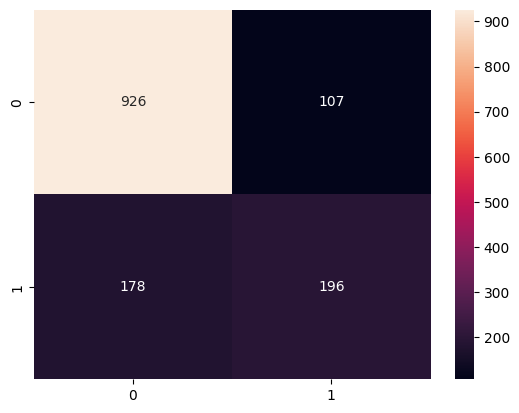

In [45]:
cm=confusion_matrix(y_test,best_pred)
sns.heatmap(cm,
            annot=True,
            fmt='d')
plt.show()


In [46]:
print("Accuracy:",
      accuracy_score(y_test,best_pred))

print("Precision:",
      precision_score(y_test,best_pred))

print("Recall:",
      recall_score(y_test,best_pred))

print("F1:",
      f1_score(y_test,best_pred))

print("ROC-AUC:",
      roc_auc_score(y_test,best_prob))

Accuracy: 0.7974413646055437
Precision: 0.6468646864686468
Recall: 0.5240641711229946
F1: 0.5790251107828656
ROC-AUC: 0.841088983336008
